In [1]:
import pandas as pd

In [2]:
# 1)Create academic performaance data
# 2)scan all variables for missiing values and inconsistancies
# 3)scan all numeric variable for all outlier
# 4)Apply data transformation on dataset 

# Method to detect outlier 1)Box Plot 2) Scatter Plot 3)Z score 4) IQR
# Method to remove outlier 1) Trimming 2)Capping

In [3]:
df =pd.read_csv("student.csv")

In [4]:
print(df.head(10))

   math_score  reading_score  writing_score  placement_score  club_join_date
0        65.0           90.0           70.0             75.0          2005.0
1        75.0            NaN           76.0             74.0          2007.0
2         NaN           80.0           69.0            100.0             NaN
3        64.0           94.0           98.0            101.0          2009.0
4        70.0           80.0           95.0              NaN          2011.0
5        80.0           99.0           65.0             85.0          2013.0
6        69.0            NaN            NaN             70.0          2024.0
7        76.0           70.0            NaN             79.0          2025.0
8         NaN           87.0           75.0             89.0          2026.0
9        90.0           85.0           45.0             84.0          2026.0


In [5]:
df.describe()

,math_score,reading_score,writing_score,placement_score,club_join_date
count,8.000000,8.0000,8.000000,9.000000,9.000000
mean,73.625000,85.6250,74.125000,84.111111,2016.222222
std,8.601287,9.0859,16.839049,11.027743,8.870989
min,64.000000,70.0000,45.000000,70.000000,2005.000000
25%,68.000000,80.0000,68.000000,75.000000,2009.000000
50%,72.500000,86.0000,72.500000,84.000000,2013.000000
75%,77.000000,91.0000,80.750000,89.000000,2025.000000
max,90.000000,99.0000,98.000000,101.000000,2026.000000


In [6]:
df.isnull().sum()

math_score         2
reading_score      2
writing_score      2
placement_score    1
club_join_date     1
dtype: int64

/*
Inter quartile range: divide plot into 4 section :
Q1 (First Quartile): Separates the lowest 25% of the data
Q2 (Second Quartile / Median): Middle value of the dataset
Q3 (Third Quartile): Separates the highest 25% of the data

Interquartile Range = Upper Quartile (Q3)– Lower Quartile(Q1)
median =mid value after arrange data in sorted order
Q1 = median of lower half
Q3 = median of upper half

Outliers are values that lie outside the upper and lower limits:

Lower Limit =Q1−1.5×IQR

Upper Limit=Q3+1.5×IQR
*/

/home/pict/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


<Axes: >

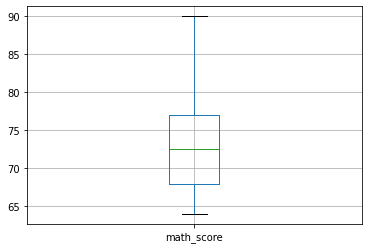

In [7]:
df.boxplot(column=['math_score'])

In [8]:
Q1=df['math_score'].quantile(0.25)
Q3=df['math_score'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
# Identify outliers
outliers = df[(df['math_score'] < lower_bound) | (df['math_score'] > upper_bound)]
print(outliers)
# To get a cleaned DataFrame (non-outliers)
df_clean = df[(df['math_score'] >= lower_bound) & (df['math_score'] <= upper_bound)]

Empty DataFrame
Columns: [math_score, reading_score, writing_score, placement_score, club_join_date]
Index: []


<Axes: >

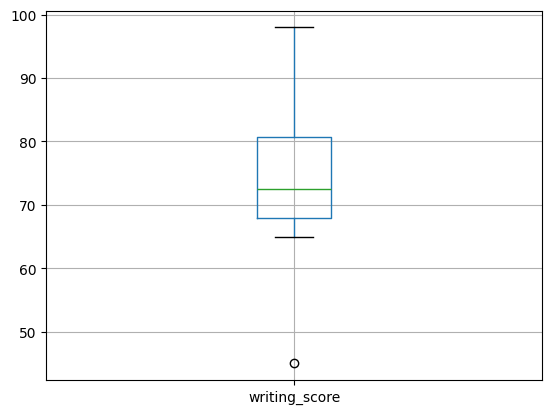

In [9]:
df.boxplot(column=['writing_score'])

In [10]:
Q1=df['writing_score'].quantile(0.25)
Q3=df['writing_score'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("lower_bound",lower_bound)
# Identify outliers
outliers = df[(df['writing_score'] < lower_bound) | (df['writing_score'] > upper_bound)]
print(outliers)
#df_clean = df[(df['math_score'] >= lower_bound) & (df['math_score'] <= upper_bound)]

lower_bound 48.875
   math_score  reading_score  writing_score  placement_score  club_join_date
9        90.0           85.0           45.0             84.0          2026.0


<Axes: >

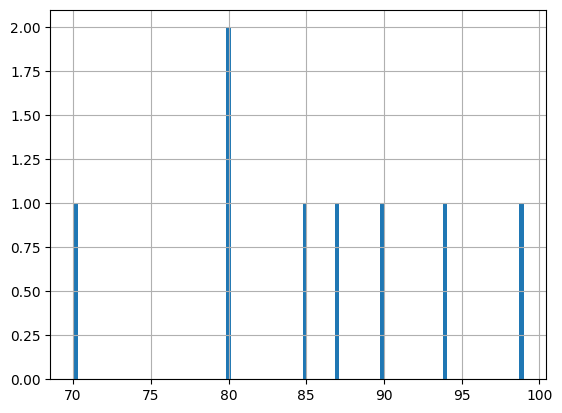

In [11]:
df['reading_score'].hist(bins=100)

<Axes: xlabel='reading_score', ylabel='math_score'>

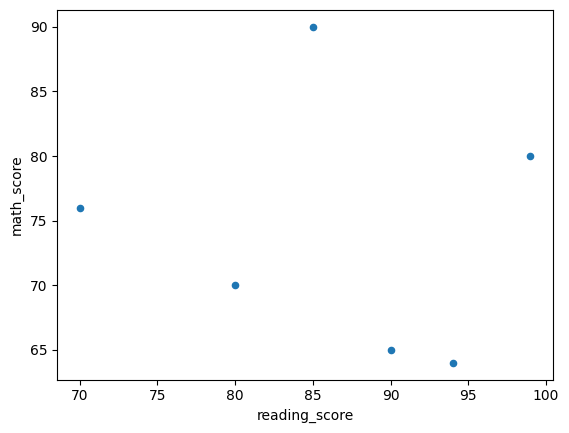

In [17]:
df.plot.scatter(x='reading_score', y='math_score')

In [14]:
import numpy as np
from scipy import stats

In [ ]:
# Calculate absolute Z-scores
z_scores = np.abs(stats.zscore(df['reading_score']))
# Identify outliers (threshold > 3)
outliers = df[z_scores > 3]
# To get a cleaned DataFrame (non-outliers)
df_clean = df[z_scores <= 3] 
print(df_clean)